## Creating a Mapper Graph using computeMapper

We may construct a mapper graph from a point cloud

In [1]:
from sklearn.datasets import make_circles

number_of_points = 500

data, labels = make_circles(n_samples=number_of_points, factor=0.4, noise=0.05, random_state=0)

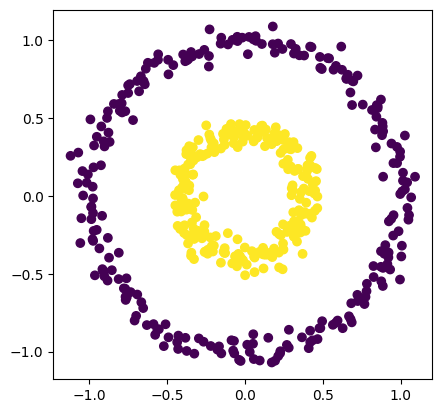

In [2]:
import matplotlib.pyplot as plt

plt.scatter(data[:, 0], data[:, 1], c=labels)
plt.axis('scaled');

We may compute the Mapper graph of this shape using computeMapper

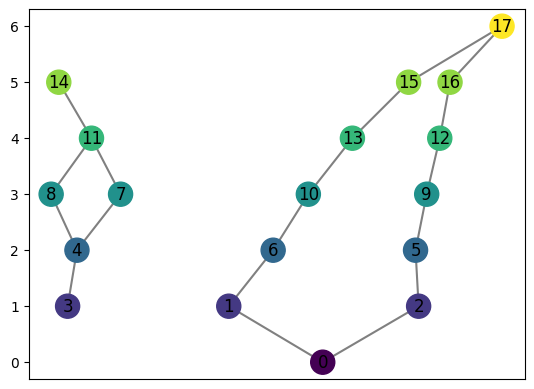

In [3]:
from cereeberus import MapperGraph, computeMapper, cover
import numpy as np


import sklearn

graph = MapperGraph()
graph = computeMapper(data, (lambda a : a[0]), cover(min=-1, max=1, numcovers=7, percentoverlap=.5), sklearn.cluster.DBSCAN(min_samples=2,eps=0.3).fit) 
graph.draw()

The computeMapper function takes 4 inputs:
- A point cloud
- A lens function
- A cover
- A clustering algorithm

Covers may be created using the cover method

In [4]:
print(cover(min=-1, max=1, numcovers=4, percentoverlap=.5))

[(-1.125, -0.375), (-0.625, 0.125), (-0.125, 0.625), (0.375, 1.125)]


Covering sets may go beyond the specified range if they have a nonzero percentage overlap with other covering sets.

Both covers and point clouds may be input manually

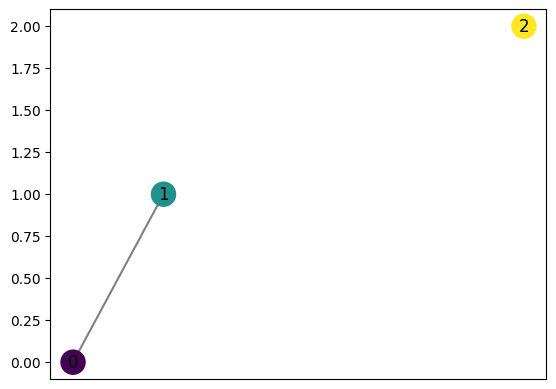

In [5]:
graph2 = computeMapper([(0.6, 0), (-0.1, 0.5)], (lambda a : a[0]), [(-1,0),(-0.5,0.5),(0,1)], "trivial")
graph2.draw()

computeMapper allows for any sklearn clustering algorithm to be used as input. It will also work with the trvial clustering.

In [6]:
from sklearn.datasets import make_moons

number_of_points = 200

data, labels = make_moons(n_samples=number_of_points, noise=0.05, random_state=0)

val = 0
pointcloud = []
while val < number_of_points:
    pointcloud.append(data[val])
    val += 1

(np.float64(-1.2259004307319845),
 np.float64(2.1731624220868624),
 np.float64(-0.6639113257043391),
 np.float64(1.162391196195627))

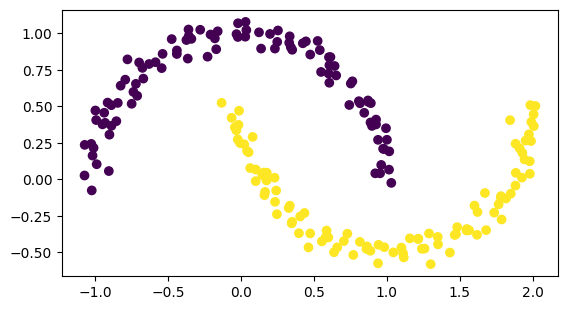

In [7]:
import matplotlib.pyplot as plt

plt.scatter(data[:, 0], data[:, 1], c=labels)
plt.axis('scaled')

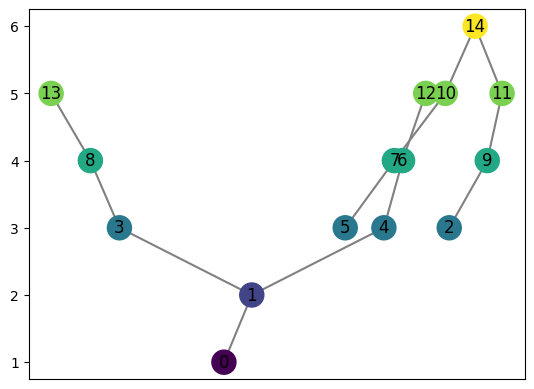

In [8]:
graph = MapperGraph()
graph = computeMapper(pointcloud, (lambda a : a[1]), cover(min=-1, max=1, numcovers=7, percentoverlap=.4), sklearn.cluster.DBSCAN(min_samples=2,eps=0.3).fit) 
graph.draw()

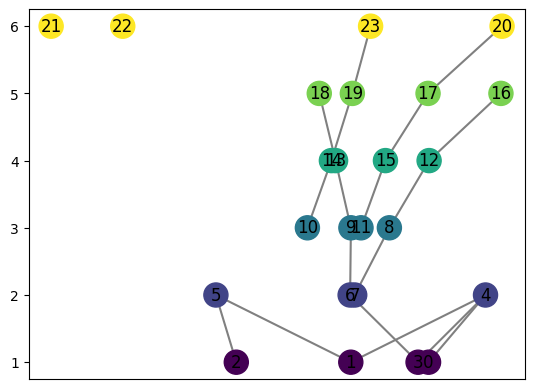

In [9]:
graph = MapperGraph()
graph = computeMapper(pointcloud, (lambda a : a[1]), cover(min=-1, max=1, numcovers=7, percentoverlap=.4), sklearn.cluster.KMeans(n_clusters=4).fit) 
graph.draw()

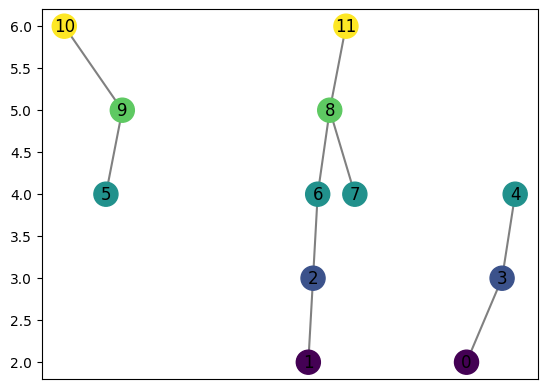

In [10]:
graph = MapperGraph()
graph = computeMapper(pointcloud, (lambda a : a[1]), cover(min=-1, max=1, numcovers=7, percentoverlap=.4), sklearn.cluster.HDBSCAN(min_cluster_size=8).fit) 
graph.draw()

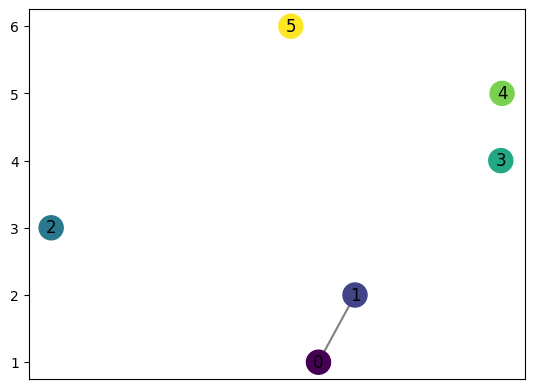

In [11]:
graph = MapperGraph()
graph = computeMapper(pointcloud, (lambda a : a[1]), cover(min=-1, max=1, numcovers=7, percentoverlap=.4), "trivial") 
graph.draw()

computeMapper orders the coveringsets it takes as input, preserving the location of each for better computing the distances between graphs

Notice where the labels for the graph start

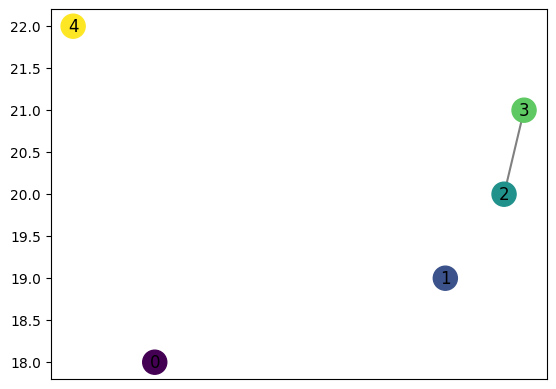

In [12]:
graph = MapperGraph()
graph = computeMapper(pointcloud, (lambda a : a[1]), cover(min=-10, max=10, numcovers=40, percentoverlap=.4), "trivial") 
graph.draw()

computeMapper accepts any function recognizable by numpy as input

In [13]:
from sklearn.datasets import make_swiss_roll
number_of_points = 300

data, labels = make_swiss_roll(n_samples=number_of_points, noise=0.1, random_state=0)

val = 0
pointcloud = []
while val < number_of_points:
    pointcloud.append((data[val][0],data[val][2]))
    val += 1

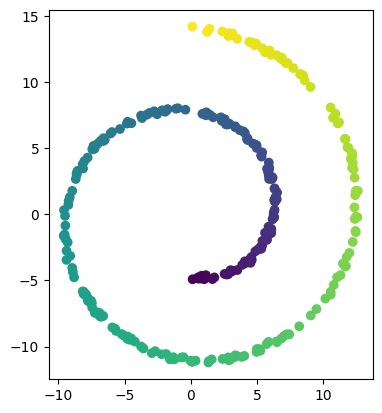

In [14]:
import matplotlib.pyplot as plt

plt.scatter(data[:, 0], data[:, 2], c=labels)
plt.axis('scaled');

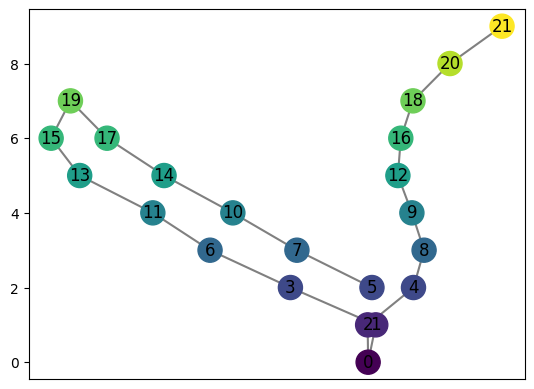

In [15]:
graph = MapperGraph()
graph = computeMapper(pointcloud, (lambda a : a[1]), cover(min=-12, max=15, numcovers=10, percentoverlap=.4), sklearn.cluster.DBSCAN(min_samples=2,eps=3).fit) 
graph.draw()

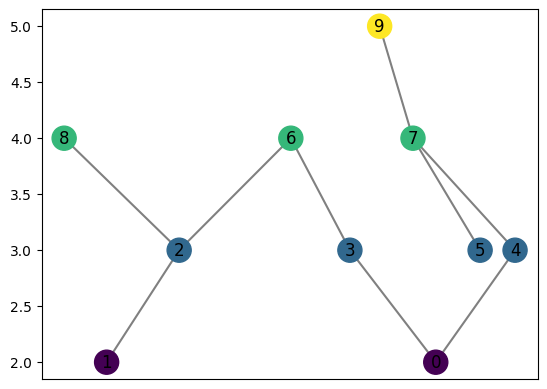

In [16]:
graph = MapperGraph()
graph = computeMapper(pointcloud, (lambda a : a[1] * a[0]), cover(min=-200, max=200, numcovers=7, percentoverlap=.4), sklearn.cluster.DBSCAN(min_samples=2,eps=3).fit) 
graph.draw()

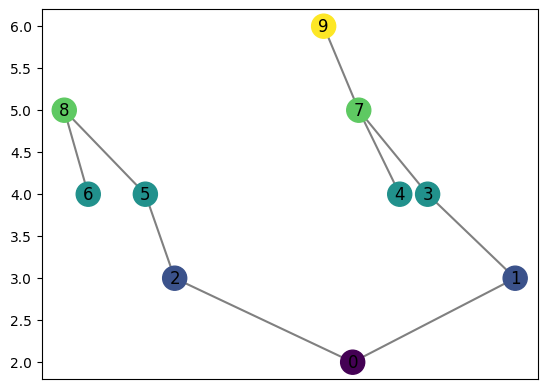

In [17]:
graph = MapperGraph()
graph = computeMapper(pointcloud, (lambda a : np.sqrt(a[0]+15)), cover(min=0, max=6, numcovers=7, percentoverlap=.4), sklearn.cluster.DBSCAN(min_samples=2,eps=3).fit) 
graph.draw()

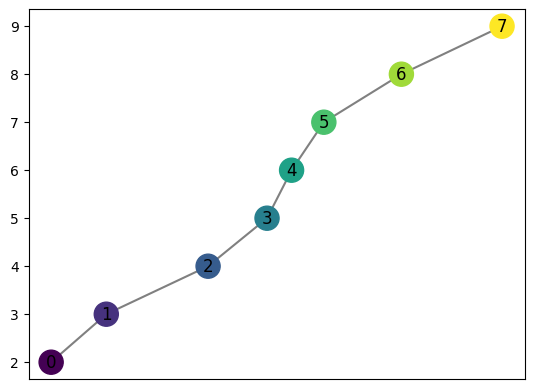

In [18]:
graph = MapperGraph()
graph = computeMapper(pointcloud, (lambda a : np.sqrt(a[0]**2 + a[1]**2)), cover(min=0, max=15, numcovers=10, percentoverlap=.4), sklearn.cluster.DBSCAN(min_samples=2,eps=3).fit) 
graph.draw()